In [1]:
# Cell 1: Imports

import os
import sys

import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Add IntegrAO to path
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

from integrao.integrater import integrao_integrater, integrao_predictor

print("Torch CUDA available:", torch.cuda.is_available())


Torch CUDA available: False


In [2]:
# Cell 2: Hyperparameters & result directory

neighbor_size = 20
embedding_dims = 64
fusing_iteration = 30
normalization_factor = 1.0
alighment_epochs = 1000
beta = 1.0
mu = 0.5

dataset_name = "supervised_integration_feature_importance"
cluster_number = 4

result_dir = os.path.join(module_path, "results", dataset_name)
os.makedirs(result_dir, exist_ok=True)

result_dir


'/Users/sofijaorlovic/Desktop/sofka/epfl/ML4science/results/supervised_integration_feature_importance'

In [3]:
# Cell 3: Load pickled TCGA-BRCA omics

data_dir = "./../data/TCGA-BRCA/"
omics = ["mRNA", "DNAm", "RPPA"]

data = {}
for omic in omics:
    with open(f"{data_dir}{omic}.pkl", "rb") as f:
        data[omic] = pickle.load(f)

list(data.keys()), list(data["mRNA"].keys())


(['mRNA', 'DNAm', 'RPPA'], ['expr', 'meta'])

In [4]:
# Cell 4: Build intersection and keep full (union) copies

dna = data["DNAm"]["expr"]
rna = data["mRNA"]["expr"]
rppa = data["RPPA"]["expr"]

# full (union) copies for incomplete-omics inference later
dna_full = dna.copy()
rna_full = rna.copy()
rppa_full = rppa.copy()

# intersection: patients that have all 3 omics
all_samples = dna.index.intersection(rna.index).intersection(rppa.index)

dna = dna.loc[all_samples]
rna = rna.loc[all_samples]
rppa = rppa.loc[all_samples]

dna.shape, rna.shape, rppa.shape


((401, 100000), (401, 29995), (401, 464))

In [5]:
# Cell 5: Encode PAM50 labels for intersection samples

labels_raw = data["DNAm"]["meta"].loc[all_samples, "paper_BRCA_Subtype_PAM50"]

label_encoder = LabelEncoder()
labels_numeric = label_encoder.fit_transform(labels_raw) + 1  # map to 1..4

pam50_classes = list(label_encoder.classes_)
print("PAM50 class mapping (1-based):")
for i, c in enumerate(pam50_classes, start=1):
    print(f"{c}: {i}")

truelabel = pd.DataFrame({
    "subjects": labels_raw.index,
    "cluster.id": labels_numeric
})

truelabel.head(), truelabel["cluster.id"].value_counts()


PAM50 class mapping (1-based):
Basal: 1
Her2: 2
LumA: 3
LumB: 4


(       subjects  cluster.id
 0  TCGA-E9-A228           4
 1  TCGA-HN-A2NL           1
 2  TCGA-OL-A5D7           1
 3  TCGA-A2-A3KC           3
 4  TCGA-A2-A0YI           3,
 cluster.id
 3    230
 4     82
 1     61
 2     28
 Name: count, dtype: int64)

In [6]:
# Cell 6: Variance-based feature selection + full matrices

views_expr = {
    "dna": dna,
    "rna": rna,
    "rppa": rppa,
}

data_fs = {}
feature_lists = {}

n_keep = 2000

for view_name, expr_df in views_expr.items():
    if view_name == "rppa":
        # RPPA is low-dimensional already
        expr_sel = expr_df.copy()
        feature_lists[view_name] = expr_sel.columns
    else:
        feature_var = expr_df.var(axis=0, skipna=True)
        top_features = feature_var.sort_values(ascending=False).head(n_keep).index
        expr_sel = expr_df.loc[:, top_features]
        feature_lists[view_name] = top_features

    data_fs[view_name] = expr_sel

# Training (intersection) views
methyl  = data_fs["rna"]
expr    = data_fs["dna"]
protein = data_fs["rppa"]

print("Intersection feature-shapes:")
print("methyl:", methyl.shape, "expr:", expr.shape, "protein:", protein.shape)

# Full (union) feature-selected matrices using same feature sets
dna_full_fs = dna_full.loc[:, feature_lists["dna"]]
rna_full_fs = rna_full.loc[:, feature_lists["rna"]]
rppa_full_fs = rppa_full.loc[:, feature_lists["rppa"]]

methyl_full  = rna_full_fs
expr_full    = dna_full_fs
protein_full = rppa_full_fs

print("Union feature-shapes:")
print("methyl_full:", methyl_full.shape, 
      "expr_full:", expr_full.shape, 
      "protein_full:", protein_full.shape)


Intersection feature-shapes:
methyl: (401, 2000) expr: (401, 2000) protein: (401, 464)
Union feature-shapes:
methyl_full: (500, 2000) expr_full: (500, 2000) protein_full: (500, 464)


In [7]:
# Cell 7: Metric helper

def get_metrics(preds, preds_index, X_test, y_test, return_preds=False):
    """
    preds: numpy array of predictions for all patients in the UNION dataset
    preds_index: index (or index-like) corresponding to preds (union patient IDs)
    X_test: index of test patients (intersection only)
    y_test: ground-truth labels for test patients (1..4)
    """
    # Handle case where preds_index might be a dict (e.g. sample -> idx)
    if isinstance(preds_index, dict):
        index_for_df = list(preds_index.keys())
    else:
        index_for_df = preds_index

    pred_df = pd.DataFrame(preds, index=index_for_df)

    # extract only test patients
    pred_df_test = pred_df.loc[X_test]

    # Integrao predictions are 0-based class indices; convert back to 1..4
    pred_labels = pred_df_test.iloc[:, 0] + 1

    f1_micro = f1_score(y_test, pred_labels, average="micro")
    f1_weighted = f1_score(y_test, pred_labels, average="weighted")
    acc = accuracy_score(y_test, pred_labels)

    if return_preds:
        return f1_micro, f1_weighted, acc, pred_labels
    else:
        return f1_micro, f1_weighted, acc


In [12]:
# Cell 8: 5-fold Stratified CV with union-based inference and unlabeled union in unsup training

K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

all_results = []
conf_matrices = []

# Intersection patients (have all 3 omics + PAM50 label)
common_patient = methyl.index
y_all = truelabel.set_index("subjects").loc[common_patient, "cluster.id"].values

# Union of all patients that appear in *any* omics (incomplete omics allowed)
union_patients = (
    methyl_full.index
    .union(expr_full.index)
    .union(protein_full.index)
)

# Extra patients: in union but not in the full-omics intersection
extra_patients = union_patients.difference(common_patient)

print(f"Intersection patients: {len(common_patient)}")
print(f"Union patients:        {len(union_patients)}")
print(f"Extra (union-only):    {len(extra_patients)}")

fold_id = 1

for train_idx, test_idx in skf.split(common_patient, y_all):
    print(f"\n========== Fold {fold_id} / {K} ==========")

    # --- 1) Train / test split on INTERSECTION patients only ---
    X_train = common_patient[train_idx]
    X_test  = common_patient[test_idx]
    y_train = y_all[train_idx]
    y_test  = y_all[test_idx]

    # ---- 2) Build the set used for UNSUPERVISED training ----
    # Option A (strict): unsup_patients = X_train
    # Option B (recommended): train intersection + unlabeled union-only patients
    #unsup_patients = X_train.union(extra_patients)
    unsup_patients = X_train

    print(f"  Train (intersection) patients: {len(X_train)}")
    print(f"  Test  (intersection) patients: {len(X_test)}")
    print(f"  Unsup patients (train + extra union): {len(unsup_patients)}")

    # Views for unsupervised integration (train + unlabeled union-only)
    methyl_unsup  = methyl_full.loc[unsup_patients]
    expr_unsup    = expr_full.loc[unsup_patients]
    protein_unsup = protein_full.loc[unsup_patients]


    # ---- 3) Unsupervised integration on UNSUPERVISED patients only ----
    integrater = integrao_integrater(
        [methyl_unsup, expr_unsup, protein_unsup],
        dataset_name,
        modalities_name_list=["methyl", "expr", "protein"],
        neighbor_size=neighbor_size,
        embedding_dims=embedding_dims,
        fusing_iteration=fusing_iteration,
        normalization_factor=normalization_factor,
        alighment_epochs=alighment_epochs,
        beta=beta,
        mu=mu,
    )

    # Build fused graphs for these patients
    integrater.network_diffusion()

    # Graph fusion + GNN embedding (unsupervised)
    embeds_final, S_final, model = integrater.unsupervised_alignment()

    # ---- 4) Supervised fine-tuning on TRAIN intersection patients only ----
    # Prepare labels (0-based for IntegrAO)
    truelabel_sub = truelabel.set_index("subjects").loc[X_train].copy()
    truelabel_sub["cluster.id"] -= 1  # convert 1..4 -> 0..3

    embeds_final, S_final, model, preds_sup = integrater.classification_finetuning(
        truelabel_sub,
        result_dir,
        finetune_epochs=800,
    )

    # Save per-fold model
    model_path = os.path.join(result_dir, f"model_fold{fold_id}.pth")
    torch.save(model.state_dict(), model_path)

    # ---- 5) Build predictor on UNION datasets for inference ----
    # (now test patients enter the graph, but the model is already trained)
    predictor = integrao_predictor(
        [methyl_full, expr_full, protein_full],
        dataset_name,
        modalities_name_list=["methyl", "expr", "protein"],
        neighbor_size=neighbor_size,
        embedding_dims=embedding_dims,
        fusing_iteration=fusing_iteration,
        normalization_factor=normalization_factor,
        alighment_epochs=alighment_epochs,
        beta=beta,
        mu=mu,
        num_classes=cluster_number,
    )

    # Fuse union graphs (no learning here, just setting up diffusion structure)
    predictor.network_diffusion()

    # Inference for ALL union patients (intersection + extra)
    preds = predictor.inference_supervised(
        model_path,
        new_datasets=[methyl_full, expr_full, protein_full],
        modalities_names=["methyl", "expr", "protein"],
    )

    # sample order used by predictor
    preds_index = predictor.dict_sampleToIndexs  # works with get_metrics

    # ---- 6) Evaluate this fold *only* on X_test (intersection) ----
    f1_micro, f1_weighted, acc, pred_labels = get_metrics(
        preds, preds_index, X_test, y_test, return_preds=True
    )

    print(
        f"Fold {fold_id} results: "
        f"F1_micro={f1_micro:.3f}  "
        f"F1_weighted={f1_weighted:.3f}  "
        f"Acc={acc:.3f}"
    )

    all_results.append((f1_micro, f1_weighted, acc))

    # confusion matrix for this fold (labels 1..4)
    cm = confusion_matrix(y_test, pred_labels, labels=[1, 2, 3, 4])
    conf_matrices.append(cm)

    fold_id += 1

# convert to array
all_results = np.array(all_results)


Intersection patients: 401
Union patients:        658
Extra (union-only):    257

========== Fold 1 / 5 ==========
  Train (intersection) patients: 320
  Test  (intersection) patients: 81
  Unsup patients (train + extra union): 320
Start indexing input expression matrices!
Common sample between view0 and view1: 320
Common sample between view0 and view2: 320
Common sample between view1 and view2: 320
Neighbor size: 20
Start applying diffusion!
Diffusion ends! Times: 2.9821341037750244s
Starting unsupervised exmbedding extraction!
Dataset 0: (320, 2000)
Dataset 1: (320, 2000)
Dataset 2: (320, 464)
epoch 0: loss 24.141767501831055, align_loss:0.791952
epoch 100: loss 19.86686897277832, align_loss:0.240030
epoch 200: loss 0.9214569926261902, align_loss:0.127081
epoch 300: loss 0.9204646944999695, align_loss:0.126586
epoch 400: loss 0.9193071126937866, align_loss:0.125983
epoch 500: loss 0.9180029630661011, align_loss:0.125269
epoch 600: loss 0.9165863394737244, align_loss:0.124549
epoch 70

/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/integrao/supervised_train.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


epoch 100: loss 2.2315187454223633, kl_loss:0.921122, align_loss:0.196956, clf_loss:1.113441
epoch 200: loss 0.8379176259040833, kl_loss:0.739573, align_loss:0.092070, clf_loss:0.006275
epoch 300: loss 0.8344678282737732, kl_loss:0.737325, align_loss:0.091407, clf_loss:0.005736
epoch 400: loss 0.8309713006019592, kl_loss:0.734682, align_loss:0.090995, clf_loss:0.005294
epoch 500: loss 0.8274539709091187, kl_loss:0.732011, align_loss:0.090567, clf_loss:0.004875
epoch 600: loss 0.8239046335220337, kl_loss:0.729255, align_loss:0.090246, clf_loss:0.004403
epoch 700: loss 0.8205370903015137, kl_loss:0.726591, align_loss:0.089929, clf_loss:0.004017
Manifold alignment ends! Times: 27.23435688018799s
Start indexing input expression matrices!
Common sample between view0 and view1: 415
Common sample between view0 and view2: 414
Common sample between view1 and view2: 414
Neighbor size: 20
Start applying diffusion!
Diffusion ends! Times: 7.414963245391846s
IntegrAO(
  (feature): ModuleList(
    (0

/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/integrao/integrater.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_loc

Fold 1 results: F1_micro=0.901  F1_weighted=0.896  Acc=0.901

========== Fold 2 / 5 ==========
  Train (intersection) patients: 321
  Test  (intersection) patients: 80
  Unsup patients (train + extra union): 321
Start indexing input expression matrices!
Common sample between view0 and view1: 321
Common sample between view0 and view2: 321
Common sample between view1 and view2: 321
Neighbor size: 20
Start applying diffusion!
Diffusion ends! Times: 2.2778480052948s
Starting unsupervised exmbedding extraction!
Dataset 0: (321, 2000)
Dataset 1: (321, 2000)
Dataset 2: (321, 464)
epoch 0: loss 24.169591903686523, align_loss:0.787692
epoch 100: loss 19.968183517456055, align_loss:0.220835
epoch 200: loss 0.9461593627929688, align_loss:0.125902
epoch 300: loss 0.9449612498283386, align_loss:0.125074
epoch 400: loss 0.9435802102088928, align_loss:0.124169
epoch 500: loss 0.9420515894889832, align_loss:0.123227
epoch 600: loss 0.9403884410858154, align_loss:0.122304
epoch 700: loss 0.938581109046

...

Fold 4 results: F1_micro=0.850  F1_weighted=0.849  Acc=0.850

========== Fold 5 / 5 ==========
  Train (intersection) patients: 321
  Test  (intersection) patients: 80
  Unsup patients (train + extra union): 321
Start indexing input expression matrices!
Common sample between view0 and view1: 321
Common sample between view0 and view2: 321
Common sample between view1 and view2: 321
Neighbor size: 20
Start applying diffusion!
Diffusion ends! Times: 2.1624701023101807s
Starting unsupervised exmbedding extraction!
Dataset 0: (321, 2000)
Dataset 1: (321, 2000)
Dataset 2: (321, 464)
epoch 0: loss 24.276020050048828, align_loss:0.763443
epoch 100: loss 19.976463317871094, align_loss:0.250778
epoch 200: loss 0.9403672218322754, align_loss:0.126169
epoch 300: loss 0.9392470121383667, align_loss:0.125615
epoch 400: loss 0.937973141670227, align_loss:0.124990
epoch 500: loss 0.9365723133087158, align_loss:0.124405
epoch 600: loss 0.9350724220275879, align_loss:0.123785
epoch 700: loss 0.9334893226

/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/integrao/supervised_train.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


epoch 100: loss 1.9339008331298828, kl_loss:1.169819, align_loss:0.297758, clf_loss:0.466324
epoch 200: loss 0.8966007232666016, kl_loss:0.793670, align_loss:0.098860, clf_loss:0.004071
epoch 300: loss 0.8925036191940308, kl_loss:0.790465, align_loss:0.098177, clf_loss:0.003862
epoch 400: loss 0.8881227970123291, kl_loss:0.787086, align_loss:0.097422, clf_loss:0.003615
epoch 500: loss 0.8836022019386292, kl_loss:0.783600, align_loss:0.096659, clf_loss:0.003343
epoch 600: loss 0.8788995146751404, kl_loss:0.780036, align_loss:0.095807, clf_loss:0.003057
epoch 700: loss 0.8739666938781738, kl_loss:0.776310, align_loss:0.094871, clf_loss:0.002786
Manifold alignment ends! Times: 26.379987955093384s
Start indexing input expression matrices!
Common sample between view0 and view1: 415
Common sample between view0 and view2: 414
Common sample between view1 and view2: 414
Neighbor size: 20
Start applying diffusion!
Diffusion ends! Times: 7.305481910705566s
IntegrAO(
  (feature): ModuleList(
    (

/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/integrao/integrater.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_loc

Fold 5 results: F1_micro=0.812  F1_weighted=0.799  Acc=0.812


In [13]:
# Cell 9: Summary metrics

f1_micro_mean    = all_results[:, 0].mean()
f1_micro_std     = all_results[:, 0].std()

f1_weighted_mean = all_results[:, 1].mean()
f1_weighted_std  = all_results[:, 1].std()

acc_mean         = all_results[:, 2].mean()
acc_std          = all_results[:, 2].std()

print("\n===== Final Cross-Validation Results =====")
print(f"F1_micro:    mean = {f1_micro_mean:.4f}, std = {f1_micro_std:.4f}")
print(f"F1_weighted: mean = {f1_weighted_mean:.4f}, std = {f1_weighted_std:.4f}")
print(f"Accuracy:    mean = {acc_mean:.4f}, std = {acc_std:.4f}")



===== Final Cross-Validation Results =====
F1_micro:    mean = 0.8527, std = 0.0324
F1_weighted: mean = 0.8483, std = 0.0343
Accuracy:    mean = 0.8527, std = 0.0324


## Methodology

### Datasets and Modalities

We used three TCGA-BRCA omics datasets representing mRNA expression, DNA methylation, and RPPA proteomics. Each dataset contained 500 patient samples, but only a subset of patients had complete measurements across all three omics.

#### Intersection dataset (fully observed patients).
Patients with all three omics available (mRNA, DNAm, RPPA) were identified, yielding
$$
\text{Intersection patients} = 401.
$$
These 401 patients also had PAM50 subtype annotations and were therefore used as the supervised labeled dataset.

#### Union dataset (partially observed patients).
Taking the union of all patients present in any omics dataset yielded
$$
\text{Union patients} = 658,
$$
of which
$$
\text{Extra (union-only) patients} = 257
$$
were partially observed (missing one or more omics) and lacked PAM50 labels. These patients were not used for model training but were included during inference, consistent with the IntegrAO framework for incorporating incomplete-omics samples in a transductive manner.

#### Cross-Validation Strategy

We performed 5-fold stratified cross-validation using only the 401 fully observed, labeled patients.  
For each fold $ k \in \{1,\dots,5\} $:

- approximately 80\% (about 320 patients) were assigned to the training set,
- approximately 20\% (about 81 patients) were assigned to the test set,

with stratification ensuring that PAM50 subtype proportions were preserved.  
Only the complete-omics patients were used for CV splitting to prevent data leakage.

#### Unsupervised Graph Integration (Training Fold Only)

IntegrAO training proceeded in two stages.  
In Stage~1, unsupervised manifold alignment was performed exclusively on the training patients (about 320 samples in each fold). For each omics modality $ m \in \{\text{mRNA}, \text{DNAm}, \text{RPPA}\} $, we extracted the training subset
$$
X_{\text{train}}^{(m)} \in \mathbb{R}^{n_{\text{train}} \times d_m}.
$$

IntegrAO then performed:

1. patient similarity graph construction for each modality,
2. graph diffusion,
3. multi-view graph fusion using only the training patients,
4. shared low-dimensional embedding learning via a GraphSAGE-based encoder.

No test samples or partially observed union-only samples were included in this step.  
Thus, the unsupervised embeddings were trained solely on the training fold, fully preventing transductive leakage.

### Supervised Fine-Tuning (Training Fold Only)

In Stage~2, IntegrAO’s classification head was fine-tuned using only the labeled training patients.  
Let
$$
y_{\text{train}} \in \{0,1,2,3\}^{n_{\text{train}}}
$$
denote the PAM50 subtype labels.  
The fine-tuning procedure optimized a combination of:

- KL-divergence reconstruction loss,
- cross-view alignment loss,
- cross-entropy classification loss (training patients only).

No unlabeled or test samples contributed to the supervised optimization.

### Inference Using the Union Dataset

After training, subtype predictions were generated using a predictor initialized with the fine-tuned parameters.  
Following the IntegrAO design, we applied the predictor to the entire union dataset (658 patients).  
This allowed partially observed patients to participate in graph fusion during inference, improving neighborhood structure and message passing.

Crucially, the model parameters were frozen during inference, so no test labels or union-only samples influenced the trained model.  
Thus, this transductive inference step does not constitute data leakage.

### Evaluation Protocol

Although predictions were produced for all 658 patients, evaluation was restricted strictly to the held-out test patients from the intersection set (about 81 patients per fold).  
For each fold, we computed:

- accuracy,
- micro-averaged F1 score,
- weighted F1 score,

along with a confusion matrix over the four PAM50 classes.  
Final performance metrics were obtained by averaging results across all five folds.

This protocol provides fair supervised evaluation while exploiting IntegrAO’s ability to incorporate incomplete-omics samples only at inference time.

### Summary of Data Flow Per Fold

| **Stage**               | **Dataset Used**       | **Size**        | **Purpose**                      | **Leakage-Free?**       |
|-------------------------|-------------------------|-----------------|----------------------------------|--------------------------|
| CV Split                | Intersection            | 401             | Train/test split                 | Yes                      |
| Unsupervised training   | Training intersection   | ≈ 320           | Embedding + fusion               | Yes                      |
| Supervised fine-tuning  | Training intersection   | ≈ 320           | Classifier training              | Yes                      |
| Inference               | Union dataset           | 658             | Graph fusion + forward pass      | Yes (frozen model)       |
| Evaluation              | Test intersection       | ≈ 81            | Metric computation               | Yes                      |



/var/folders/tt/c0ph4yks47qf6jml4nwy1yb00000gn/T/ipykernel_67553/4219046381.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_results, labels=metric_names)


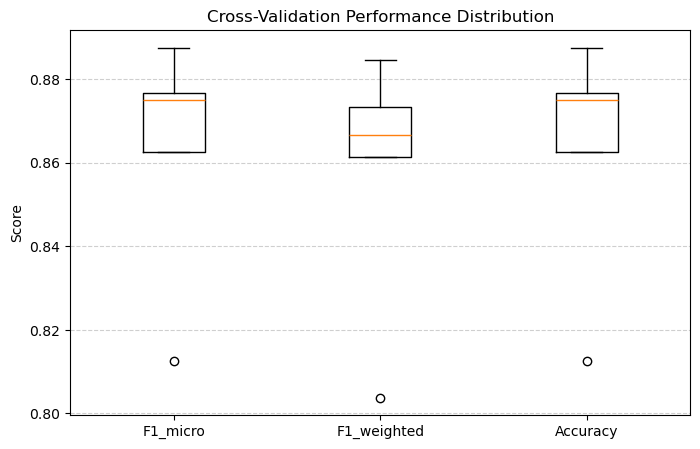

In [34]:
# Cell 10: Boxplot of CV metrics

metric_names = ["F1_micro", "F1_weighted", "Accuracy"]

plt.figure(figsize=(8, 5))
plt.boxplot(all_results, labels=metric_names)
plt.title("Cross-Validation Performance Distribution")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


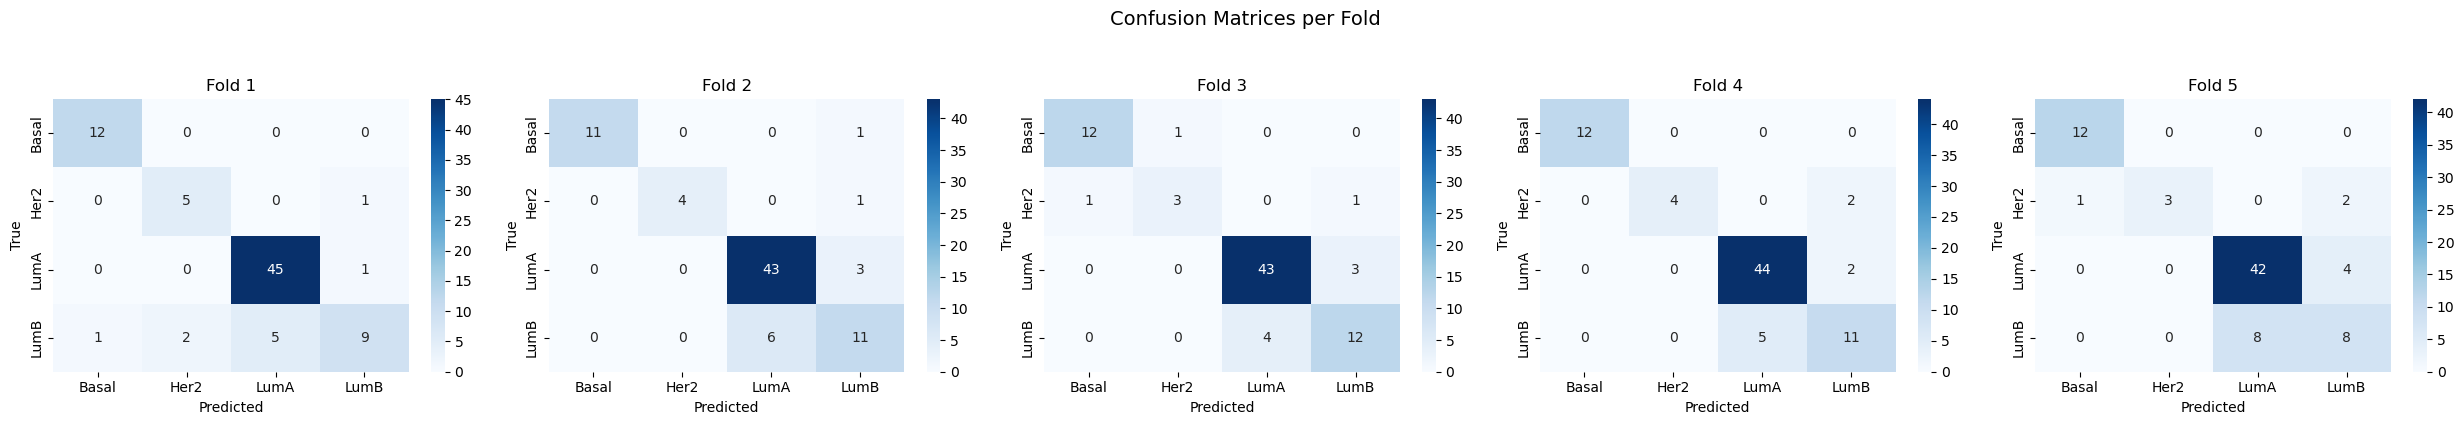

In [35]:
# Cell 11: Confusion matrices per fold

num_folds = len(conf_matrices)
fig, axes = plt.subplots(1, num_folds, figsize=(5 * num_folds, 4), squeeze=False)

for i, cm in enumerate(conf_matrices):
    ax = axes[0, i]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=pam50_classes,
        yticklabels=pam50_classes,
        ax=ax,
    )
    ax.set_title(f"Fold {i+1}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices per Fold", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


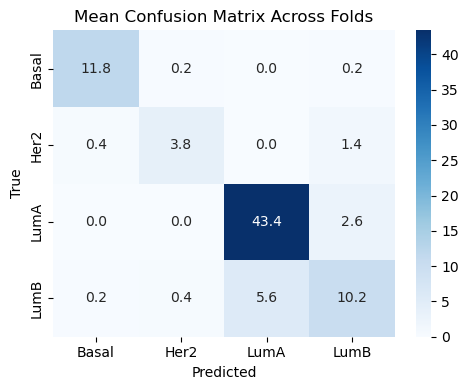

In [36]:
# Cell 12: Mean confusion matrix

mean_conf = np.mean(conf_matrices, axis=0)

plt.figure(figsize=(5, 4))
sns.heatmap(
    mean_conf,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=pam50_classes,
    yticklabels=pam50_classes,
)
plt.title("Mean Confusion Matrix Across Folds")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [15]:
from sklearn.manifold import UMAP

# Extract embeddings from predictor (after network_diffusion)
# Predictor stores the final aligned embeddings in predictor.embeds_final
# But some versions don't expose it; this is safer:

embeddings = predictor.embeds  # if available
patient_ids = list(predictor.dict_sampleToIndexs.keys())

emb_df = pd.DataFrame(embeddings, index=patient_ids)

# Reduce to 2D using UMAP
umap = UMAP(n_components=2, random_state=42)
coords = umap.fit_transform(emb_df)

plt.figure(figsize=(7,6))
plt.scatter(coords[:,0], coords[:,1], s=10, alpha=0.8)
plt.title("UMAP of IntegrAO Embeddings (Union Patients)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()


ImportError: cannot import name 'UMAP' from 'sklearn.manifold' (/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/sklearn/manifold/__init__.py)

In [16]:
from sklearn.manifold import TSNE

coords = TSNE(n_components=2, learning_rate='auto').fit_transform(emb_df)

plt.figure(figsize=(7,6))
plt.scatter(coords[:,0], coords[:,1], c=preds.flatten()+1, cmap='viridis', s=8)
plt.title("t-SNE of IntegrAO Embeddings Colored by Predicted PAM50")
plt.xlabel("tSNE1")
plt.ylabel("tSNE2")
plt.colorbar()
plt.show()


NameError: name 'emb_df' is not defined

In [37]:
# Cell: Interpretability — train model on ALL intersection patients

# Use full intersection dataset
methyl_int  = methyl        # (401, 2000)
expr_int    = expr          # (401, 2000)
protein_int = protein       # (401, 464)

# Prepare labels (0-based for integrater)
labels_int = truelabel.set_index("subjects")["cluster.id"] - 1
labels_int = labels_int.loc[methyl_int.index]  # aligned order

# 1) Unsupervised integration
integrater_int = integrao_integrater(
    [methyl_int, expr_int, protein_int],
    dataset_name,
    modalities_name_list=["methyl","expr","protein"],
    neighbor_size=neighbor_size,
    embedding_dims=embedding_dims,
    fusing_iteration=fusing_iteration,
    normalization_factor=normalization_factor,
    alighment_epochs=alighment_epochs,
    beta=beta,
    mu=mu,
)

integrater_int.network_diffusion()
embeds_int, S_int, model_int = integrater_int.unsupervised_alignment()

# 2) Supervised fine-tuning on ALL labels
labels_int_df = pd.DataFrame({"cluster.id": labels_int.values}, index=labels_int.index)

embeds_int, S_int, model_int, preds_int = integrater_int.classification_finetuning(
    labels_int_df,
    result_dir,
    finetune_epochs=800,
)

# Save interpretability model
model_path_int = os.path.join(result_dir, "model_for_interpretation.pth")
torch.save(model_int.state_dict(), model_path_int)


Start indexing input expression matrices!
Common sample between view0 and view1: 401
Common sample between view0 and view2: 401
Common sample between view1 and view2: 401
Neighbor size: 20
Start applying diffusion!
Diffusion ends! Times: 5.274952173233032s
Starting unsupervised exmbedding extraction!
Dataset 0: (401, 2000)
Dataset 1: (401, 2000)
Dataset 2: (401, 464)
epoch 0: loss 24.90381622314453, align_loss:0.808403
epoch 100: loss 20.583927154541016, align_loss:0.242957
epoch 200: loss 1.1004993915557861, align_loss:0.134832
epoch 300: loss 1.099120855331421, align_loss:0.134404
epoch 400: loss 1.0975421667099, align_loss:0.133856
epoch 500: loss 1.0958144664764404, align_loss:0.133229
epoch 600: loss 1.0939501523971558, align_loss:0.132528
epoch 700: loss 1.0920376777648926, align_loss:0.132036
epoch 800: loss 1.0900452136993408, align_loss:0.131384
epoch 900: loss 1.0879857540130615, align_loss:0.130851
Manifold alignment ends! Times: 43.864357233047485s
Starting supervised finet

/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/integrao/supervised_train.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


epoch 0: loss 2.762486457824707, kl_loss:1.001057, align_loss:0.118229, clf_loss:1.643201
epoch 100: loss 1.638669729232788, kl_loss:1.094404, align_loss:0.232049, clf_loss:0.312216
epoch 200: loss 0.9766780138015747, kl_loss:0.885069, align_loss:0.088864, clf_loss:0.002746
epoch 300: loss 0.9742926955223083, kl_loss:0.883253, align_loss:0.088346, clf_loss:0.002694
epoch 400: loss 0.9717791080474854, kl_loss:0.881347, align_loss:0.087781, clf_loss:0.002651
epoch 500: loss 0.9691790342330933, kl_loss:0.879359, align_loss:0.087210, clf_loss:0.002610
epoch 600: loss 0.9664763808250427, kl_loss:0.877299, align_loss:0.086610, clf_loss:0.002567
epoch 700: loss 0.9636960029602051, kl_loss:0.875266, align_loss:0.085915, clf_loss:0.002516
Manifold alignment ends! Times: 33.40482687950134s


In [38]:
# Build predictor on the SAME intersection dataset
predictor_int = integrao_predictor(
    [methyl_int, expr_int, protein_int],
    dataset_name,
    modalities_name_list=["methyl","expr","protein"],
    neighbor_size=neighbor_size,
    embedding_dims=embedding_dims,
    fusing_iteration=fusing_iteration,
    normalization_factor=normalization_factor,
    alighment_epochs=alighment_epochs,
    beta=beta,
    mu=mu,
    num_classes=cluster_number,
)

predictor_int.network_diffusion()

# Run integrated gradients to extract feature attributions
df_list = predictor_int.interpret_supervised(
    model_path=model_path_int,
    result_dir=result_dir,
    new_datasets=[methyl_int, expr_int, protein_int],
    modalities_names=["methyl","expr","protein"]
)


Start indexing input expression matrices!
Common sample between view0 and view1: 401
Common sample between view0 and view2: 401
Common sample between view1 and view2: 401
Neighbor size: 20
Start applying diffusion!
Diffusion ends! Times: 4.93410587310791s
IntegrAO(
  (feature): ModuleList(
    (0-1): 2 x GraphSAGE(2000, 64, num_layers=2)
    (2): GraphSAGE(464, 64, num_layers=2)
  )
  (feature_show): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
    (3): Linear(in_features=64, out_features=64, bias=True)
  )
  (pred_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1, inplace=True)
    (3): Linear(in_features=32, out_features=4, bias=True)
  )
)
Loaded pre-trained model

/opt/miniconda3/envs/mlenv/lib/python3.10/site-packages/integrao/integrater.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_loc

(401, 2000)
Saved feature importances for domain methyl to /Users/sofijaorlovic/Desktop/sofka/epfl/ML4science/results/supervised_integration_feature_importance/methyl_feat_importance.csv
(401, 2000)
Saved feature importances for domain expr to /Users/sofijaorlovic/Desktop/sofka/epfl/ML4science/results/supervised_integration_feature_importance/expr_feat_importance.csv
(401, 464)
Saved feature importances for domain protein to /Users/sofijaorlovic/Desktop/sofka/epfl/ML4science/results/supervised_integration_feature_importance/protein_feat_importance.csv


In [39]:
# Cell: Aggregate feature importances

feature_importances = {}

for name, df in zip(["methyl", "expr", "protein"], df_list):
    mean_scores = df.abs().mean(axis=0)     # average over all patients
    feature_importances[name] = mean_scores.sort_values(ascending=False)

feature_importances_corrected = {
    "mRNA": feature_importances["methyl"],     # genes
    "DNAm": feature_importances["expr"],       # CpG sites
    "RPPA": feature_importances["protein"]     # proteins
}

feature_importances_corrected["mRNA"].head(20)
feature_importances_corrected["DNAm"].head(20)
feature_importances_corrected["RPPA"].head(20)


feat_164    0.000607
feat_187    0.000530
feat_175    0.000394
feat_143    0.000310
feat_163    0.000270
feat_55     0.000249
feat_360    0.000237
feat_12     0.000236
feat_387    0.000213
feat_229    0.000208
feat_206    0.000205
feat_386    0.000205
feat_16     0.000204
feat_297    0.000201
feat_219    0.000198
feat_282    0.000189
feat_313    0.000185
feat_211    0.000183
feat_146    0.000182
feat_78     0.000180
dtype: float64

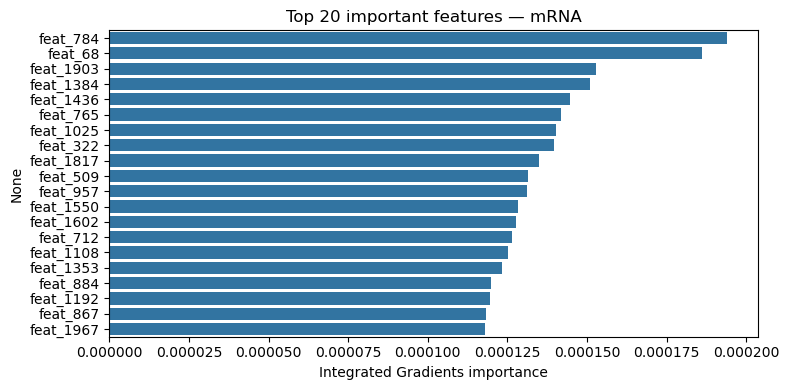

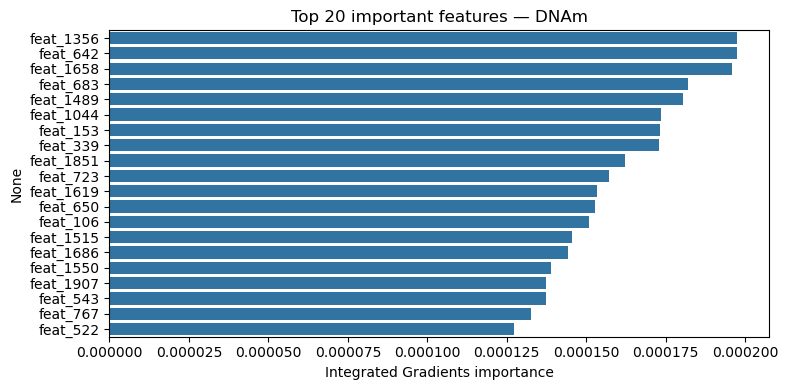

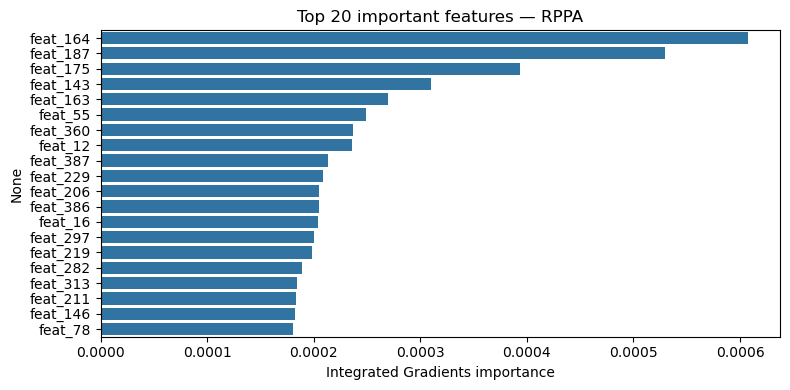

In [40]:
for name in ["mRNA", "DNAm" , "RPPA"]:
    top20 = feature_importances_corrected[name].head(20)
    plt.figure(figsize=(8,4))
    sns.barplot(x=top20.values, y=top20.index, orient='h')
    plt.title(f"Top 20 important features — {name}")
    plt.xlabel("Integrated Gradients importance")
    plt.tight_layout()
    plt.show()


In [22]:
# CLASS-SPECIFIC INTEGRATED GRADIENTS

import torch
from captum.attr import IntegratedGradients

def get_class_specific_ig(predictor, model_path, 
                          new_datasets, modalities_names, 
                          target_class):
    """
    Runs Integrated Gradients for a specific class (0-based PAM50 class ID).
    Returns: list of DataFrames [IG_mRNA, IG_DNAm, IG_RPPA]
    """
    
    # Load model weights
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = predictor.model
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    
    # build x_dict of feature matrices
    x_dict = predictor._make_x_dict(new_datasets, modalities_names)
    edge_index_dict = predictor.edge_index_dict
    domain_order = predictor.dict_original_order

    # For each modality run IG separately
    df_list = []

    for domain_idx, domain in enumerate(modalities_names):

        # x_input = features for this domain only (requires grad)
        x_input = torch.tensor(x_dict[domain], dtype=torch.float32, device=device, requires_grad=True)

        # Static (non-updated) features for other views
        static_x = {k: torch.tensor(v, dtype=torch.float32, device=device)
                    for k, v in x_dict.items() if k != domain}

        ig = IntegratedGradients(
            lambda x: model({**static_x, domain: x},
                            edge_index_dict,
                            domain_order)[2][:, target_class]
        )

        attributions = ig.attribute(
            inputs=x_input,
            target=None,
            return_convergence_delta=False
        )

        # Move to pandas
        df = pd.DataFrame(
            attributions.detach().cpu().numpy(), 
            index=new_datasets[0].index,   # same patient ordering for all views
            columns=x_dict[domain].columns
        )
        df_list.append(df)

    return df_list
